# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook содержит код для обучения модели ResNet18 на датасете Train_1 и оценки качества на Test_1.

## 1. Импорт библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import json
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
RUNS_DIR = Path('runs')
RUNS_DIR.mkdir(exist_ok=True)

training_params = {
    'experiment_name': 'baseline_train1',
    'model_name': 'resnet18',
    'pretrained': True,
    'num_classes': 2,
    'train_csv': 'ai-vs-human-generated-dataset-hw/Train_1/train.csv',
    'train_root': 'ai-vs-human-generated-dataset-hw/Train_1',
    'test_csv': 'ai-vs-human-generated-dataset-hw/Test_1/test.csv',
    'test_root': 'ai-vs-human-generated-dataset-hw/Test_1',
    'image_size': 224,
    'batch_size': 8,
    'num_epochs': 10,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'scheduler': 'StepLR',
    'scheduler_step_size': 5,
    'scheduler_gamma': 0.1,
}

run_dir = RUNS_DIR / f"{training_params['experiment_name']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir.mkdir(parents=True, exist_ok=True)
with open(run_dir / 'params.json', 'w', encoding='utf-8') as params_file:
    json.dump(training_params, params_file, ensure_ascii=False, indent=2)

writer = SummaryWriter(log_dir=str(run_dir))
writer.add_text('params', json.dumps(training_params, ensure_ascii=False, indent=2))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Подготовка данных

In [2]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.root_dir / self.data.iloc[idx]['file_name']
        image = Image.open(img_path).convert('RGB')
        label = int(self.data.iloc[idx]['label'])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((training_params['image_size'], training_params['image_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((training_params['image_size'], training_params['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(
    csv_file=training_params['train_csv'],
    root_dir=training_params['train_root'],
    transform=train_transform
)

test_dataset = ImageDataset(
    csv_file=training_params['test_csv'],
    root_dir=training_params['test_root'],
    transform=test_transform
)

batch_size = training_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

print(f'Model architecture:')
print(model)

Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

## 4. Определение функции потерь и оптимизатора

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=training_params['learning_rate'])
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=training_params['scheduler_step_size'],
    gamma=training_params['scheduler_gamma'],
)

## 5. Функция обучения

In [6]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    
    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

In [7]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary')
    epoch_precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

In [8]:
num_epochs = training_params['num_epochs']
train_losses = []
train_accs = []
train_f1s = []

best_train_f1 = 0.0
best_model_path = ARTIFACTS_DIR / 'resnet18_train1_best.pt'

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)
    
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    writer.add_scalar('train/loss', train_loss, epoch + 1)
    writer.add_scalar('train/accuracy', train_acc, epoch + 1)
    writer.add_scalar('train/f1', train_f1, epoch + 1)
    writer.add_scalar('train/learning_rate', scheduler.get_last_lr()[0], epoch + 1)
    
    if train_f1 > best_train_f1:
        best_train_f1 = train_f1
        torch.save(model.state_dict(), best_model_path)
    
    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')

torch.save(model.state_dict(), ARTIFACTS_DIR / 'resnet18_train1_last.pt')
print('\nTraining completed!')
print(f'Best Train F1: {best_train_f1:.4f}')


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 1250/1250 [00:24<00:00, 51.87it/s]


Train Loss: 0.4972, Acc: 0.7775, F1: 0.7731

Epoch 2/10
--------------------------------------------------


Training: 100%|██████████| 1250/1250 [00:23<00:00, 53.19it/s]


Train Loss: 0.4446, Acc: 0.8031, F1: 0.8023

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.2102, Acc: 0.9153, F1: 0.9150

Epoch 9/10
--------------------------------------------------


Training: 100%|██████████| 1250/1250 [00:22<00:00, 54.98it/s]


Train Loss: 0.1954, Acc: 0.9238, F1: 0.9237

Epoch 10/10
--------------------------------------------------


Training: 100%|██████████| 1250/1250 [00:23<00:00, 53.68it/s]


Train Loss: 0.1845, Acc: 0.9288, F1: 0.9286

Training completed!
Best Train F1: 0.9286


## 8. Оценка модели на тестовом датасете

Validation: 100%|██████████| 500/500 [00:06<00:00, 82.26it/s]


Test metrics on Test_1:
loss: 0.1191
accuracy: 0.9557
f1: 0.9564
precision: 0.9436
recall: 0.9695


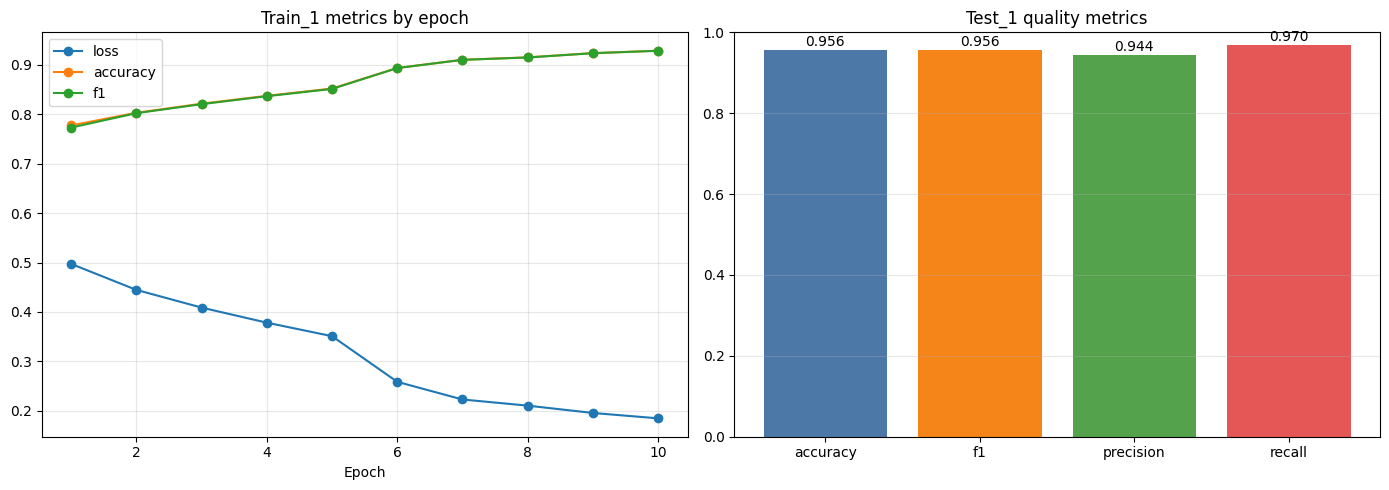

Train metrics saved to: artifacts/baseline_train1_train_metrics.csv
Test metrics saved to: artifacts/baseline_train1_test_metrics.json
Metrics plot saved to: artifacts/baseline_train1_metrics.png
TensorBoard logs saved to: runs/baseline_train1_20260522_233853


In [9]:
test_loss, test_acc, test_f1, test_precision, test_recall = validate(model, test_loader, criterion, device)

test_metrics = {
    'loss': test_loss,
    'accuracy': test_acc,
    'f1': test_f1,
    'precision': test_precision,
    'recall': test_recall,
}

print('Test metrics on Test_1:')
for metric_name, metric_value in test_metrics.items():
    writer.add_scalar(f'test/{metric_name}', metric_value, num_epochs)
    print(f'{metric_name}: {metric_value:.4f}')

train_metrics_df = pd.DataFrame({
    'epoch': list(range(1, num_epochs + 1)),
    'loss': train_losses,
    'accuracy': train_accs,
    'f1': train_f1s,
})
train_metrics_path = ARTIFACTS_DIR / 'baseline_train1_train_metrics.csv'
test_metrics_path = ARTIFACTS_DIR / 'baseline_train1_test_metrics.json'
metrics_plot_path = ARTIFACTS_DIR / 'baseline_train1_metrics.png'

train_metrics_df.to_csv(train_metrics_path, index=False)
with open(test_metrics_path, 'w', encoding='utf-8') as metrics_file:
    json.dump(test_metrics, metrics_file, ensure_ascii=False, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_metrics_df['epoch'], train_metrics_df['loss'], marker='o', label='loss')
axes[0].plot(train_metrics_df['epoch'], train_metrics_df['accuracy'], marker='o', label='accuracy')
axes[0].plot(train_metrics_df['epoch'], train_metrics_df['f1'], marker='o', label='f1')
axes[0].set_title('Train_1 metrics by epoch')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

bar_metrics = ['accuracy', 'f1', 'precision', 'recall']
axes[1].bar(bar_metrics, [test_metrics[name] for name in bar_metrics], color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Test_1 quality metrics')
axes[1].grid(True, axis='y', alpha=0.3)
for index, metric_name in enumerate(bar_metrics):
    axes[1].text(index, test_metrics[metric_name] + 0.01, f"{test_metrics[metric_name]:.3f}", ha='center')

plt.tight_layout()
fig.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Train metrics saved to: {train_metrics_path}')
print(f'Test metrics saved to: {test_metrics_path}')
print(f'Metrics plot saved to: {metrics_plot_path}')

writer.add_hparams(
    {key: str(value) for key, value in training_params.items()},
    {f'hparam/test_{key}': value for key, value in test_metrics.items()},
)
writer.flush()
writer.close()
print(f'TensorBoard logs saved to: {run_dir}')

## 8.1. Загрузка модели в S3 / MinIO

In [10]:
from minio import Minio
from minio.error import S3Error

s3_config = {
    'endpoint': 'localhost:19000',
    'access_key': 'minioadmin',
    'secret_key': 'minioadmin',
    'secure': False,
    'bucket_name': 'mlops-models',
    'object_name': 'baseline/resnet18_train1_best.pt',
}

model_artifact_path = ARTIFACTS_DIR / 'resnet18_train1_best.pt'
if not model_artifact_path.exists():
    raise FileNotFoundError(f'Model artifact not found: {model_artifact_path}')

client = Minio(
    s3_config['endpoint'],
    access_key=s3_config['access_key'],
    secret_key=s3_config['secret_key'],
    secure=s3_config['secure'],
)

try:
    if not client.bucket_exists(s3_config['bucket_name']):
        client.make_bucket(s3_config['bucket_name'])

    upload_result = client.fput_object(
        s3_config['bucket_name'],
        s3_config['object_name'],
        str(model_artifact_path),
        content_type='application/octet-stream',
    )

    s3_upload_info = {
        'bucket': s3_config['bucket_name'],
        'object': s3_config['object_name'],
        'etag': upload_result.etag,
        'version_id': upload_result.version_id,
        'source_file': str(model_artifact_path),
        'source_size_bytes': model_artifact_path.stat().st_size,
        'console_url': 'http://localhost:19001',
    }
    s3_upload_info_path = ARTIFACTS_DIR / 'baseline_train1_s3_upload.json'
    with open(s3_upload_info_path, 'w', encoding='utf-8') as upload_file:
        json.dump(s3_upload_info, upload_file, ensure_ascii=False, indent=2)

    print('Model artifact uploaded to MinIO')
    print(f"s3://{s3_upload_info['bucket']}/{s3_upload_info['object']}")
    print(f'Upload info saved to: {s3_upload_info_path}')
except S3Error as exc:
    raise RuntimeError(
        'MinIO upload failed. Check that local MinIO is running on http://localhost:19000 '
        'with login/password minioadmin/minioadmin.'
    ) from exc

Model artifact uploaded to MinIO
s3://mlops-models/baseline/resnet18_train1_best.pt
Upload info saved to: artifacts/baseline_train1_s3_upload.json


## 9. Дообучите модель на втором датасете и постройте DVC пайплайн

In [11]:
import os
import subprocess
import sys

os.environ['DVC_SITE_CACHE_DIR'] = '/tmp/dvc-site-cache'
os.environ['DVC_NO_ANALYTICS'] = 'true'

# Пайплайн делает 4 действия:
# 1. скачивает baseline-модель из MinIO;
# 2. дообучает ее на Train_2;
# 3. оценивает на Test_2;
# 4. загружает новую версию модели обратно в MinIO.
subprocess.run([sys.executable, '-m', 'dvc', 'repro'], check=True)
subprocess.run([sys.executable, '-m', 'dvc', 'dag'], check=True)

Stage 'download_baseline_model' didn't change, skipping
Running stage 'finetune_train2':
> python scripts/finetune_train2.py --params params.yaml

Finetune epoch 1/5


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.2207, Acc: 0.9214, F1: 0.9232

Finetune epoch 2/5


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.1599, Acc: 0.9400, F1: 0.9413

Finetune epoch 3/5


...

Training: 100%|██████████| 500/500 [00:08<00:00, 55.72it/s]


Loss: 0.1335, Acc: 0.9560, F1: 0.9568
Best finetune F1: 0.9570
Saved best model to: artifacts/resnet18_train2_finetuned_best.pt
Saved train metrics to: artifacts/finetune_train2_train_metrics.csv
Updating lock file 'dvc.lock'

Running stage 'evaluate_train2':
> python scripts/evaluate_train2.py --params params.yaml


Evaluation: 100%|██████████| 250/250 [00:03<00:00, 82.18it/s]


Test_2 metrics:
loss: 0.0830
accuracy: 0.9745
f1: 0.9742
precision: 0.9816
recall: 0.9668
Saved plot to: artifacts/finetune_train2_metrics.png
Updating lock file 'dvc.lock'

Running stage 'upload_finetuned_model':
> python scripts/upload_model.py --endpoint localhost:19000 --access-key minioadmin --secret-key minioadmin --bucket mlops-models --object-name finetuned/resnet18_train2_best.pt --input-path artifacts/resnet18_train2_finetuned_best.pt --upload-info-path artifacts/finetune_train2_s3_upload.json
Uploaded artifacts/resnet18_train2_finetuned_best.pt to s3://mlops-models/finetuned/resnet18_train2_best.pt
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock runs/.gitignore artifacts/.gitignore

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.
                 +-------------------------+         
                 | download_baseline_model |         
                 +----------------

CompletedProcess(args=['/home/makarov/anaconda3/envs/jupyterlab/bin/python', '-m', 'dvc', 'dag'], returncode=0)

## 10. Напишите вывод о полученных результатах

Базовая ResNet18 после обучения на Train_1 показала на Test_1 такие метрики: accuracy = 0.9557, F1 = 0.9564, precision = 0.9436, recall = 0.9695. Метрики и графики сохранены в TensorBoard (`runs/baseline_train1_20260522_233853`), `artifacts/baseline_train1_train_metrics.csv`, `artifacts/baseline_train1_test_metrics.json` и `artifacts/baseline_train1_metrics.png`. Артефакт базовой модели загружен в локальный S3/MinIO: `s3://mlops-models/baseline/resnet18_train1_best.pt`.

Дальше через DVC-пайплайн модель была скачана из MinIO, дообучена на Train_2, протестирована на Test_2 и снова загружена в MinIO. После дообучения получились метрики Test_2: accuracy = 0.9745, F1 = 0.9742, precision = 0.9816, recall = 0.9668. Новая версия модели лежит в `s3://mlops-models/finetuned/resnet18_train2_best.pt`, подтверждение загрузки сохранено в `artifacts/finetune_train2_s3_upload.json`. DVC-граф был распечатан в пункте 9, результаты дообучения сохранены в `runs/finetune_train2`, `artifacts/finetune_train2_train_metrics.csv`, `artifacts/finetune_train2_test_metrics.json` и `artifacts/finetune_train2_metrics.png`.

По сравнению с базовой моделью качество после дообучения стало лучше по accuracy и F1: F1 вырос примерно с 0.956 до 0.974. Precision заметно вырос, recall остался примерно на том же высоком уровне. В целом дообучение на Train_2 дало полезный прирост качества, поэтому финальную модель можно считать более удачной версией.